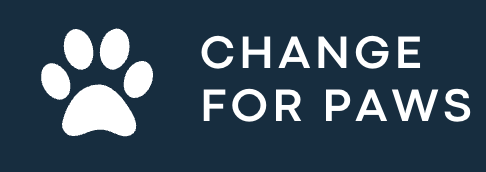

Dataset Source:

https://www.kaggle.com/datasets/jessicali9530/stanford-dogs-dataset?resource=download

http://vision.stanford.edu/aditya86/ImageNetDogs/

https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest

# **Pet Image Upload and Preprocess**

In [ ]:
!pip install numpy pandas seaborn matplotlib tensorflow keras torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

In [ ]:
from matplotlib.pyplot import imshow
from keras.preprocessing import image
from keras import applications
import os
import glob

In [ ]:
import keras
from keras import layers
from keras.layers import Input,Dense,Activation,ZeroPadding2D,BatchNormalization,Flatten,Conv2D
from keras.layers import AveragePooling2D,GlobalAveragePooling2D,GlobalMaxPool2D,MaxPooling2D,MaxPool2D,Dropout
from keras.models import Model,Sequential

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from collections import defaultdict


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = '/content/drive/MyDrive/MSDS 498/PetImages/cropped'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

def preprocess_image(image_path, img_height=224, img_width=224):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [img_height, img_width])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def load_labels(folder):
    return sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

class_names = load_labels(train_dir)
class_to_index = {name: idx for idx, name in enumerate(class_names)}

def load_image_paths_and_labels(folder):
    image_paths = []
    labels = []
    for class_name in class_names:
        class_folder = os.path.join(folder, class_name)
        if os.path.isdir(class_folder):
            for img_file in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_file)
                if os.path.isfile(img_path) and img_file.lower().endswith(('.jpg', '.jpeg')):
                    image_paths.append(img_path)
                    labels.append(class_to_index[class_name])
    return image_paths, labels


train_image_paths, train_labels = load_image_paths_and_labels(train_dir)
test_image_paths, test_labels = load_image_paths_and_labels(test_dir)

train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))

train_dataset = train_dataset.map(lambda x, y: (preprocess_image(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(lambda x, y: (preprocess_image(x), y), num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

print(f"Loaded {len(train_image_paths)} training samples.")
print(f"Loaded {len(test_image_paths)} testing samples.")

Loaded 12000 training samples.
Loaded 8580 testing samples.


# **Deep Learning for Dog Breed Classification**




## **EDA**

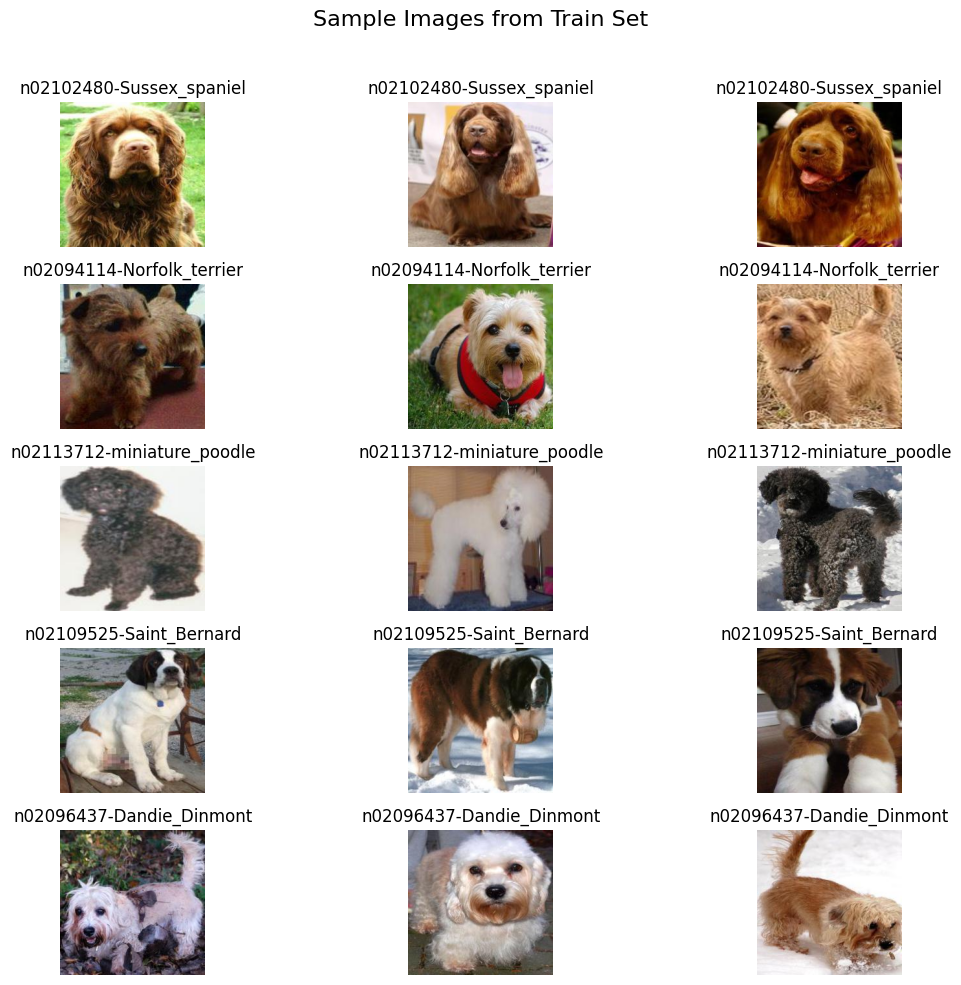

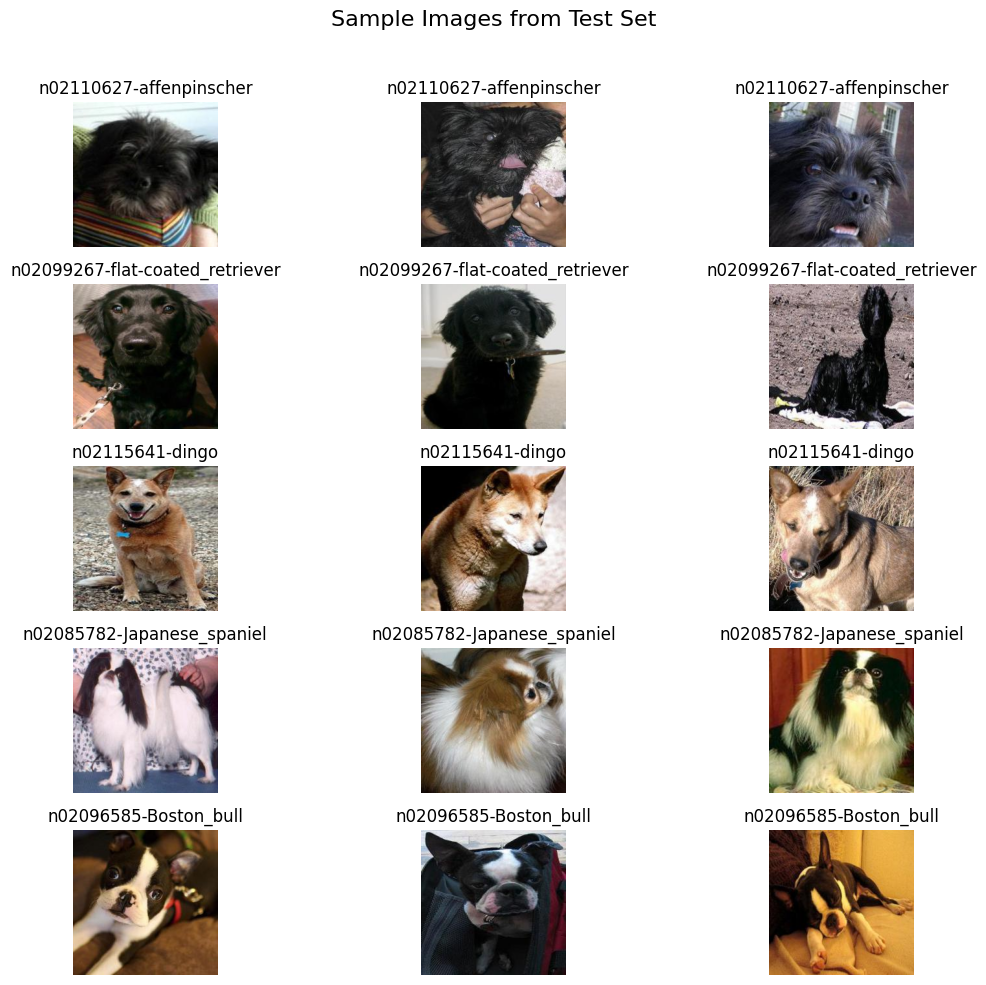

In [ ]:
def plot_sample_images(data_dir, title):
    sample_classes = random.sample(os.listdir(data_dir), 5)
    fig, axes = plt.subplots(len(sample_classes), 3, figsize=(12, 10))
    fig.suptitle(title, fontsize=16)

    for i, cls in enumerate(sample_classes):
        class_folder = os.path.join(data_dir, cls)
        image_files = random.sample(os.listdir(class_folder), 3)

        for j, img_file in enumerate(image_files):
            img_path = os.path.join(class_folder, img_file)
            img = Image.open(img_path)
            img = img.resize((224, 224))

            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{cls}")
            axes[i, j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_sample_images(train_dir, "Sample Images from Train Set")
plot_sample_images(test_dir, "Sample Images from Test Set")

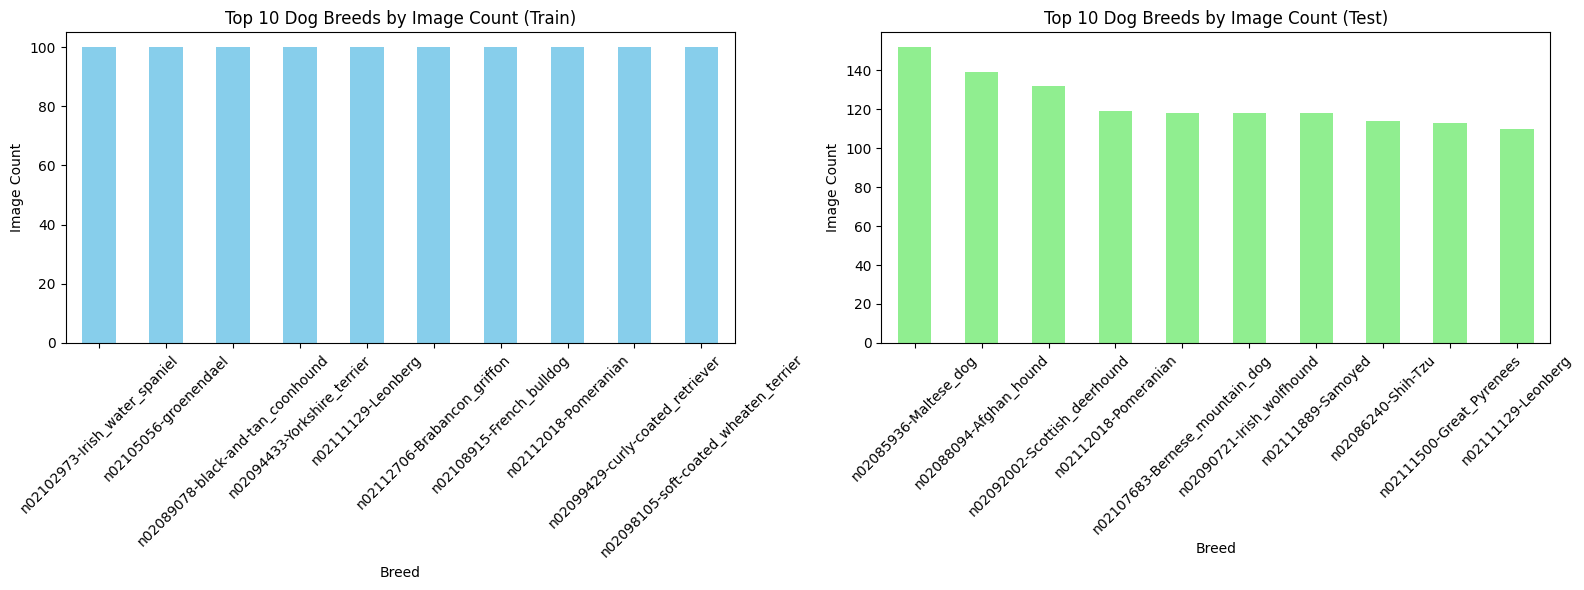

In [ ]:
def get_class_counts(directory):
    class_counts = defaultdict(int)
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
    return class_counts

train_class_counts = get_class_counts(train_dir)
test_class_counts = get_class_counts(test_dir)

df_train = pd.DataFrame.from_dict(train_class_counts, orient='index', columns=['Image Count'])
df_test = pd.DataFrame.from_dict(test_class_counts, orient='index', columns=['Image Count'])

df_train = df_train.sort_values(by='Image Count', ascending=False)
df_test = df_test.sort_values(by='Image Count', ascending=False)

top_n = 10
df_train_top = df_train.head(top_n)
df_test_top = df_test.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_train_top.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title(f'Top {top_n} Dog Breeds by Image Count (Train)')
axes[0].set_ylabel('Image Count')
axes[0].set_xlabel('Breed')
axes[0].tick_params(axis='x', rotation=45)

df_test_top.plot(kind='bar', legend=False, color='lightgreen', ax=axes[1])
axes[1].set_title(f'Top {top_n} Dog Breeds by Image Count (Test)')
axes[1].set_ylabel('Image Count')
axes[1].set_xlabel('Breed')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

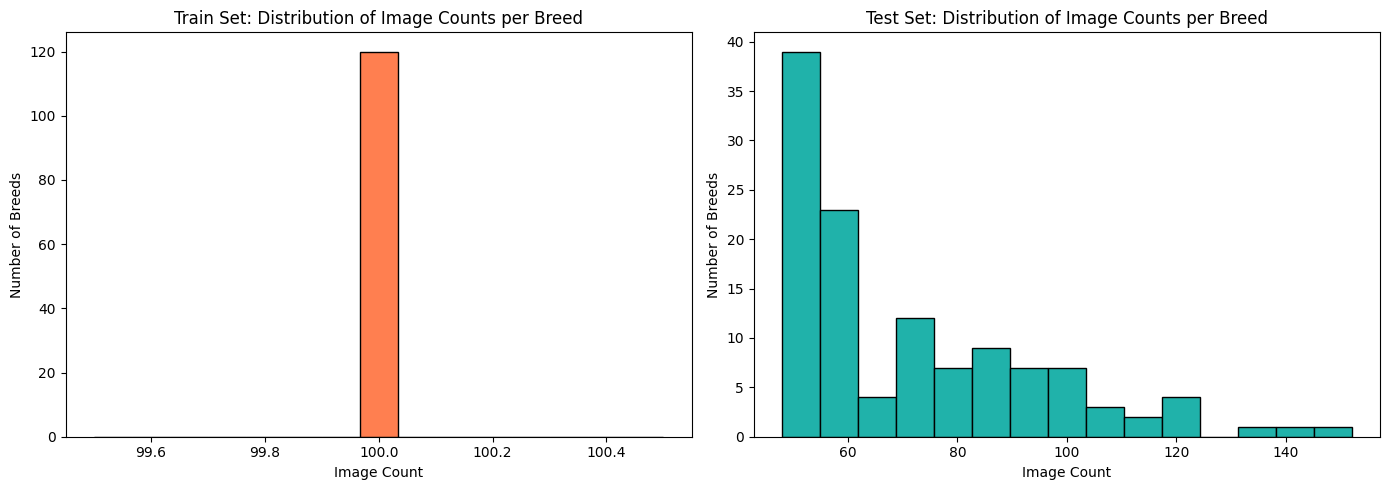

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['Image Count'], bins=15, color='coral', edgecolor='black')
axes[0].set_title('Train Set: Distribution of Image Counts per Breed')
axes[0].set_xlabel('Image Count')
axes[0].set_ylabel('Number of Breeds')

axes[1].hist(df_test['Image Count'], bins=15, color='lightseagreen', edgecolor='black')
axes[1].set_title('Test Set: Distribution of Image Counts per Breed')
axes[1].set_xlabel('Image Count')
axes[1].set_ylabel('Number of Breeds')

plt.tight_layout()
plt.show()

## **EXPERIMENTS 5/18/25**

In [ ]:
#base_dir = '/content/drive/MyDrive/MSDS 498/PetImages/cropped'
#train_dir = os.path.join(base_dir, 'train')
#test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    shuffle=True,
    seed=42
)

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(120, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    callbacks=[early_stopping, reduce_lr]
)

Found 9600 images belonging to 120 classes.
Found 2400 images belonging to 120 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4876s 16s/step - accuracy: 0.2298 - loss: 3.9379 - val_accuracy: 0.8192 - val_loss: 1.0995 - learning_rate: 1.0000e-04
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 175s 584ms/step - accuracy: 0.7417 - loss: 1.1686 - val_accuracy: 0.8346 - val_loss: 0.6584 - learning_rate: 1.0000e-04
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 203s 587ms/step - accuracy: 0.7869 - loss: 0.7890 - val_accuracy: 0.8529 - val_loss: 0.5522 - learning_rate: 1.0000e-04
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 202s 589ms/step - accuracy: 0.8191 - loss: 0.6523 - val_accuracy: 0.8487 - val_loss: 0.5124 - learning_rate: 1.0000e-04
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 176s 587ms/step - accuracy: 0.8318 - loss: 0.5721 - val_accuracy: 0.8487 - val_loss: 0.4947 - learning_rate: 1.0000e-04
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 202s 586ms/step - accu

In [ ]:
#TEST#

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)


test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Found 8580 images belonging to 120 classes.
269/269 ━━━━━━━━━━━━━━━━━━━━ 3487s 13s/step - accuracy: 0.8826 - loss: 0.3922
Test Accuracy: 0.8830
Test Loss: 0.3871


In [ ]:
#TEST ACCURACY BY CLASS#

from sklearn.metrics import classification_report

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

pred_probs = model.predict(test_generator)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_generator.classes

class_indices = test_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

report = classification_report(true_labels, pred_labels, target_names=[idx_to_class[i] for i in sorted(idx_to_class)])
print(report)


Found 8580 images belonging to 120 classes.
269/269 ━━━━━━━━━━━━━━━━━━━━ 37s 138ms/step
                                          precision    recall  f1-score   support

                     n02085620-Chihuahua       0.85      0.85      0.85        52
              n02085782-Japanese_spaniel       0.93      0.88      0.90        85
                   n02085936-Maltese_dog       0.93      0.91      0.92       152
                      n02086079-Pekinese       0.82      0.92      0.87        49
                      n02086240-Shih-Tzu       0.80      0.79      0.79       114
              n02086646-Blenheim_spaniel       0.97      0.99      0.98        88
                      n02086910-papillon       0.99      0.97      0.98        96
                   n02087046-toy_terrier       0.87      0.83      0.85        72
           n02087394-Rhodesian_ridgeback       0.81      0.79      0.80        72
                  n02088094-Afghan_hound       0.99      0.98      0.99       139
         

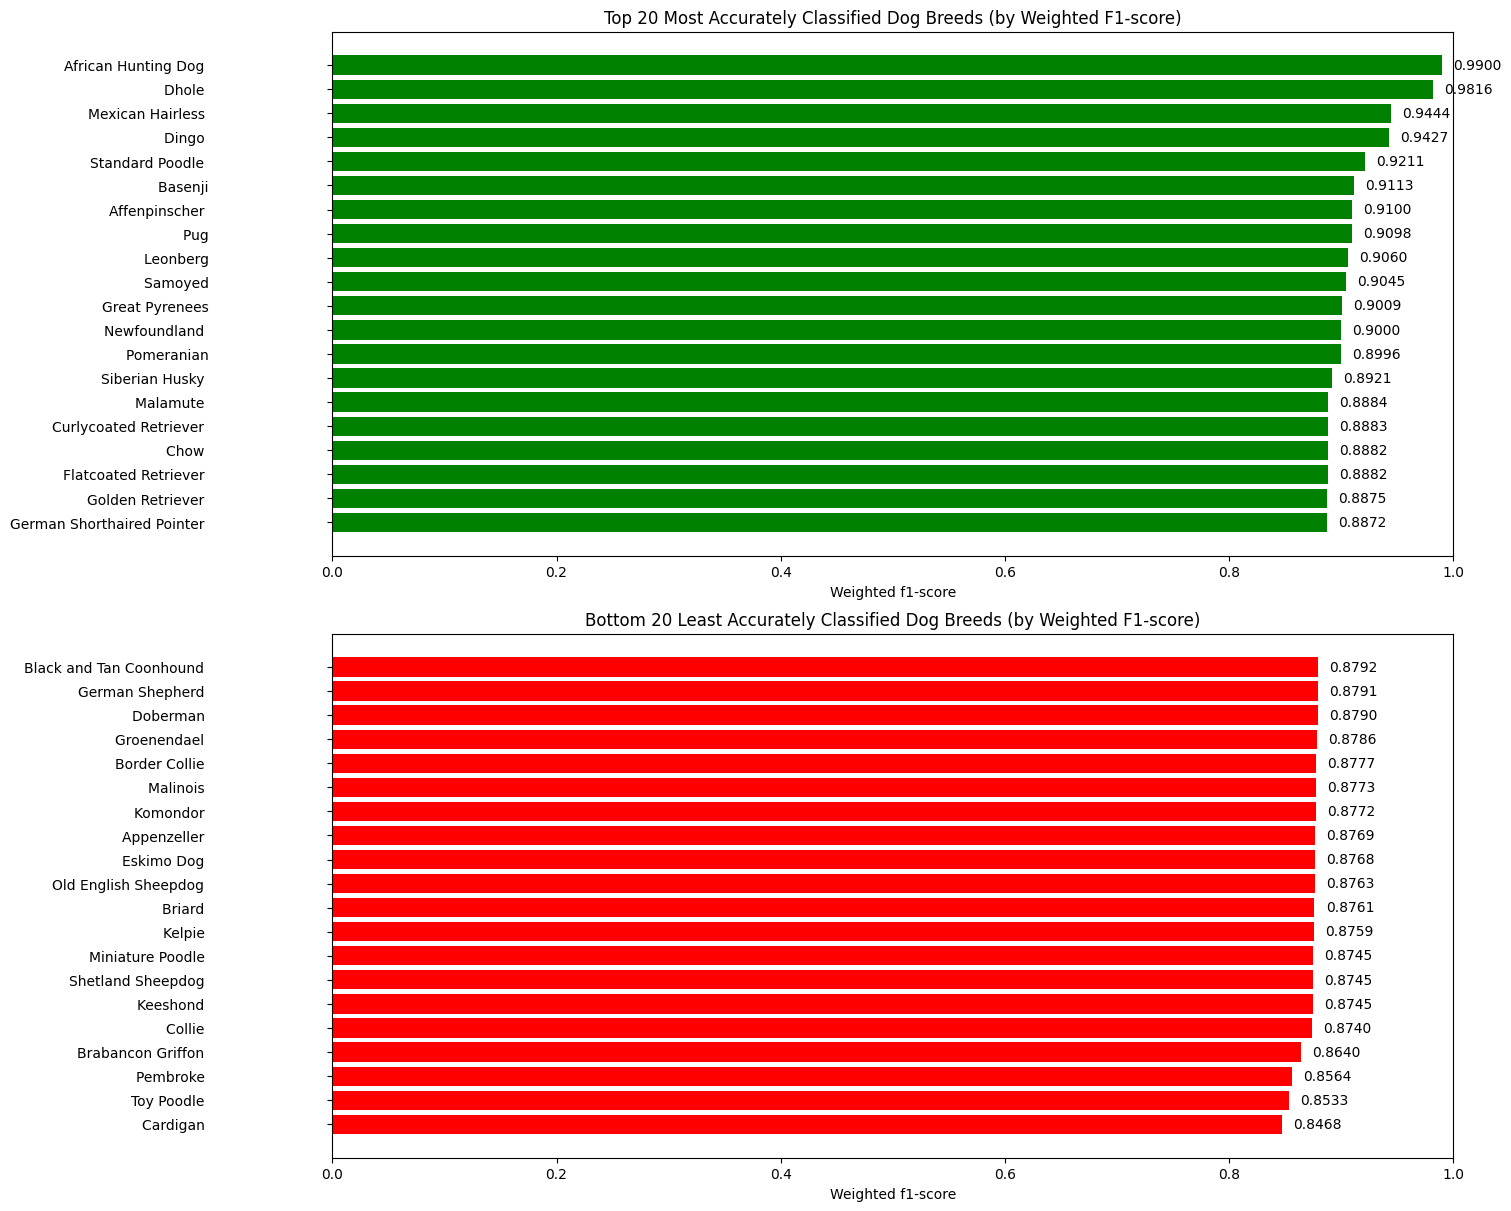

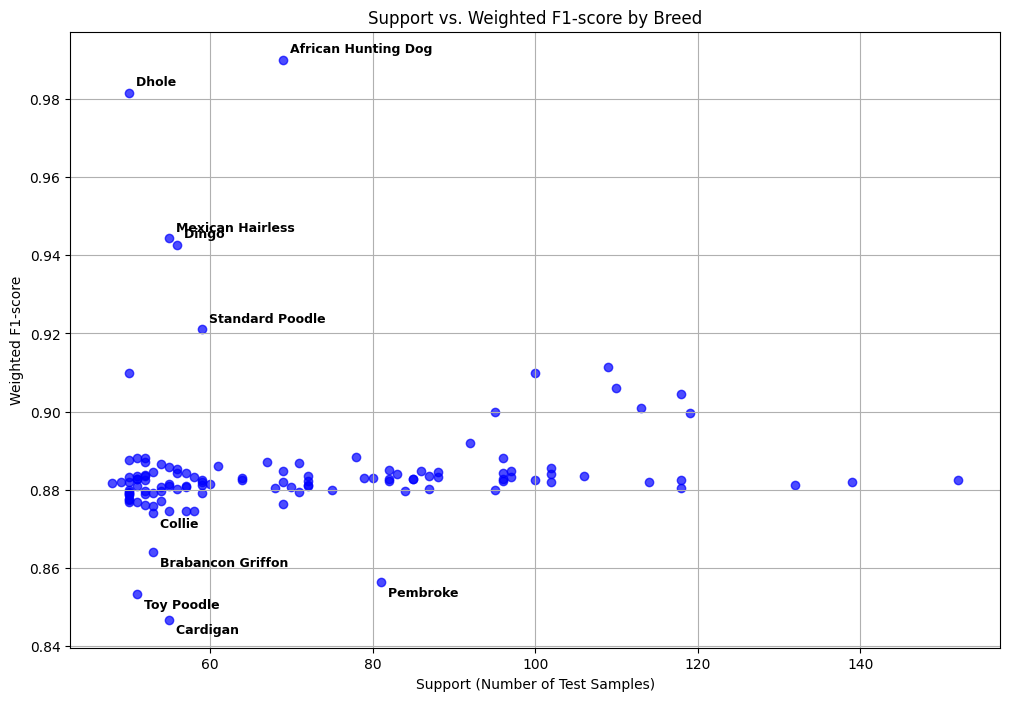

In [13]:
#BREAKDOWN BY CLASS VISUALIZATION#

import pandas as pd
import matplotlib.pyplot as plt

# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/MSDS 498 CAPSTONE/Breed Classification by Class Performance Analysis.xlsx'

df = pd.read_excel(file_path)

df = df.dropna(subset=['Weighted f1-score', 'Breed'])

df['Weighted f1-score'] = pd.to_numeric(df['Weighted f1-score'], errors='coerce')

df_sorted = df.sort_values('Weighted f1-score', ascending=False)

top_20 = df_sorted.head(20)
bottom_20 = df_sorted.tail(20)

fig, axs = plt.subplots(2, 1, figsize=(15, 12), constrained_layout=True)

axs[0].barh(top_20['Breed'], top_20['Weighted f1-score'], color='green')
axs[0].invert_yaxis()
axs[0].set_title('Top 20 Most Accurately Classified Dog Breeds (by Weighted F1-score)')
axs[0].set_xlabel('Weighted f1-score')
axs[0].set_xlim(0, 1)

for i, (score) in enumerate(top_20['Weighted f1-score']):
    axs[0].text(score + 0.01, i, f"{score:.4f}", va='center', fontsize=10)

axs[1].barh(bottom_20['Breed'], bottom_20['Weighted f1-score'], color='red')
axs[1].invert_yaxis()
axs[1].set_title('Bottom 20 Least Accurately Classified Dog Breeds (by Weighted F1-score)')
axs[1].set_xlabel('Weighted f1-score')
axs[1].set_xlim(0, 1)

for i, (score) in enumerate(bottom_20['Weighted f1-score']):
    axs[1].text(score + 0.01, i, f"{score:.4f}", va='center', fontsize=10)

plt.show()

# Scatter plot: Support vs Weighted f1-score
plt.figure(figsize=(12, 8))
plt.scatter(df['support'], df['Weighted f1-score'], alpha=0.7, color='blue')
plt.title('Support vs. Weighted F1-score by Breed')
plt.xlabel('Support (Number of Test Samples)')
plt.ylabel('Weighted F1-score')
plt.grid(True)

for i, row in df_sorted.head(5).iterrows():
    plt.annotate(row['Breed'], (row['support'], row['Weighted f1-score']),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, fontweight='bold')

for i, row in df_sorted.tail(5).iterrows():
    plt.annotate(row['Breed'], (row['support'], row['Weighted f1-score']),
                 textcoords="offset points", xytext=(5,-10), ha='left', fontsize=9, fontweight='bold')

plt.show()

## **EXPERIMENTS 5/11/25 INITIAL FINDINGS**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 121)            │        15,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,321 (169.22 KB)

 Trainable params: 43,321 (169.22 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 103s 336ms/step - accuracy: 0.0078 - loss: 4.7972 - val_accuracy: 0.0071 - val_loss: 4.7907
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 105s 348ms/step - accuracy: 0.0105 - loss: 4.7866 - val_accuracy: 0.0233 - val_loss: 4.6599
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 375ms/step - accuracy: 0.0147 - loss: 4.6378 - val_accuracy: 0.0275 - val_loss: 4.5268
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 124s 410ms/step - accuracy: 0.0203 - loss: 4.5480 - val_accuracy: 0.0308 - val_loss: 4.5012
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 124s 410ms/step - accuracy: 0.0272 - loss: 4.5117 - val_accuracy: 0.0300 - val_loss: 4.4654
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 133s 441ms/step - accuracy: 0.0273 - loss: 4.4889 - val_accuracy: 0.0325 - val_loss: 4.4516
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 149s 491ms/step - accuracy: 0.0288 - loss: 4.4544 - val_accuracy: 0.0404 - val_loss: 4.4227
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 152s 498ms/step - accuracy: 0.0301 -

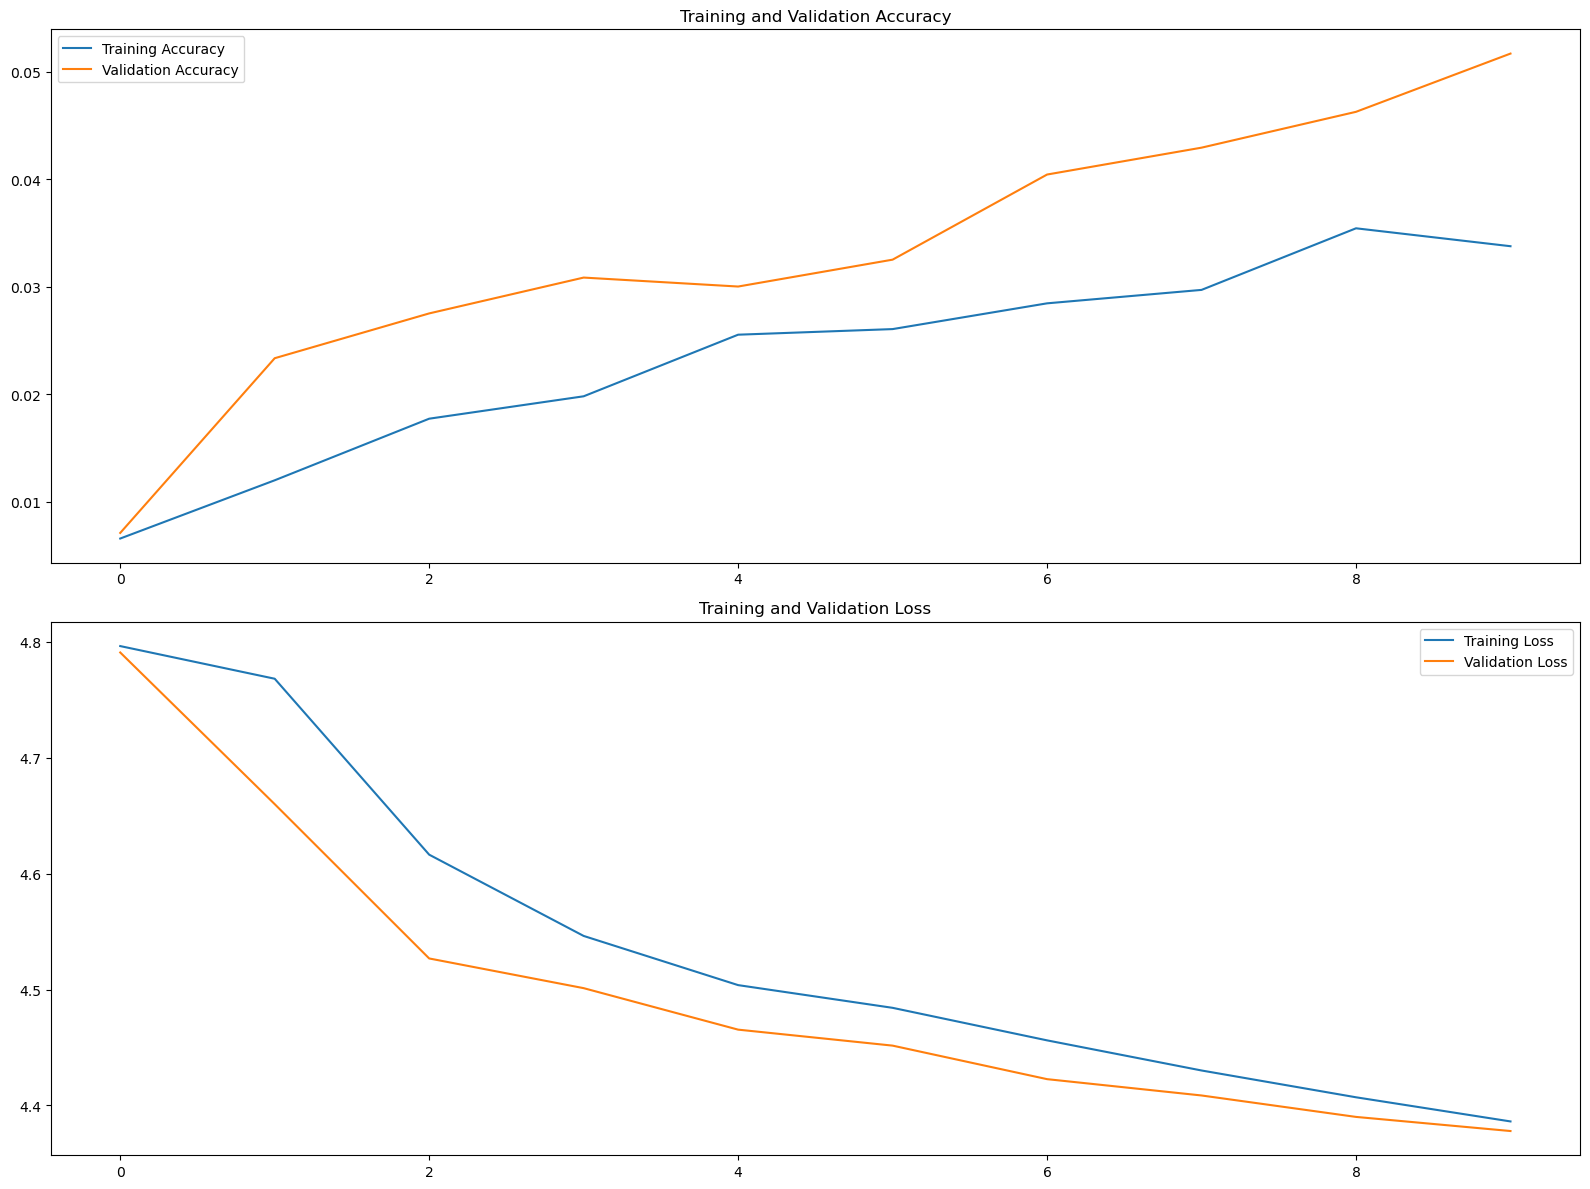

In [ ]:
# Experiment 1: CNN Model with 2 Layers and Dropout Regularization

experiment_1_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

experiment_1_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
experiment_1_cnn.summary()

history = experiment_1_cnn.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("experiment_1_cnn_model.keras", save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
    ]
)

experiment_1_cnn = tf.keras.models.load_model("experiment_1_cnn_model.keras")
test_acc = experiment_1_cnn.evaluate(test_dataset)
print(f"[Experiment 1 - Regularized CNN] Test Accuracy: {test_acc[1]:.3f}")

history_dict = history.history
history_df = pd.DataFrame(history_dict)

plt.figure(figsize=(16, 12))
plt.subplot(211)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(212)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 121)            │        15,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,865,593 (91.04 MB)

 Trainable params: 277,881 (1.06 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 557s 2s/step - accuracy: 0.0083 - loss: 4.8254 - val_accuracy: 0.0083 - val_loss: 4.7937
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.0051 - loss: 4.7937 - val_accuracy: 0.0083 - val_loss: 4.7923
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.0074 - loss: 4.7925 - val_accuracy: 0.0083 - val_loss: 4.7913
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - accuracy: 0.0072 - loss: 4.7916 - val_accuracy: 0.0083 - val_loss: 4.7906
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 973ms/step - accuracy: 0.0092 - loss: 4.7906
[Experiment 2 - ResNet50 Transfer Learning] Test Accuracy: 0.008


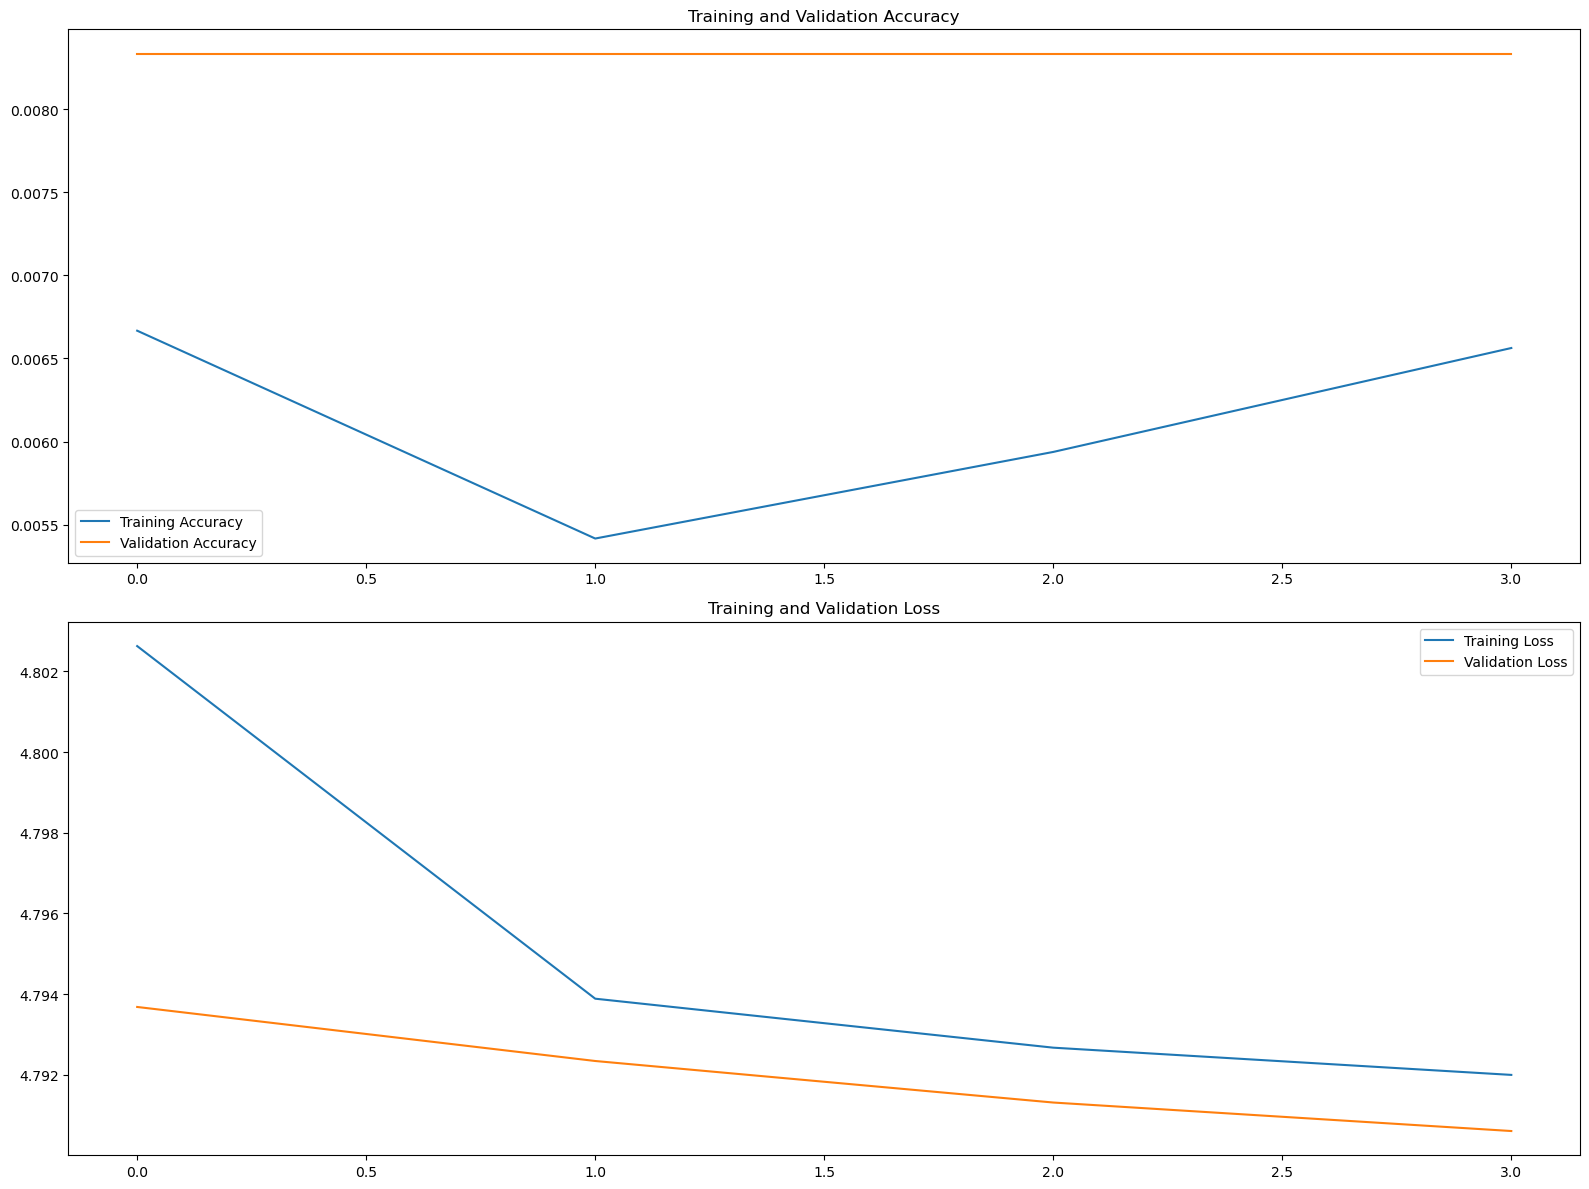

In [ ]:
# Experiment 2: Transfer Learning with ResNet50

base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

experiment_2_cnn = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])


experiment_2_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
experiment_2_cnn.summary()


history_2 = experiment_2_cnn.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("experiment_2_cnn_resnet_model.keras", save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
    ]
)


experiment_2_cnn = tf.keras.models.load_model("experiment_2_cnn_resnet_model.keras")


test_acc_2 = experiment_2_cnn.evaluate(test_dataset)
print(f"[Experiment 2 - ResNet50 Transfer Learning] Test Accuracy: {test_acc_2[1]:.3f}")


history_dict = history_2.history
history_df = pd.DataFrame(history_dict)

plt.figure(figsize=(16, 12))


plt.subplot(211)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()


plt.subplot(212)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 121)            │        15,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,705 (170.72 KB)

 Trainable params: 43,513 (169.97 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 186s 612ms/step - accuracy: 0.0129 - loss: 4.7964 - val_accuracy: 0.0162 - val_loss: 4.8076
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 227s 751ms/step - accuracy: 0.0216 - loss: 4.5599 - val_accuracy: 0.0267 - val_loss: 4.5277
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 251s 830ms/step - accuracy: 0.0307 - loss: 4.4263 - val_accuracy: 0.0333 - val_loss: 4.5588
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 288s 952ms/step - accuracy: 0.0420 - loss: 4.3462 - val_accuracy: 0.0325 - val_loss: 4.5991
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 295s 975ms/step - accuracy: 0.0509 - loss: 4.2468 - val_accuracy: 0.0421 - val_loss: 4.3496
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.0606 - loss: 4.1951 - val_accuracy: 0.0437 - val_loss: 4.3808
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 286s 946ms/step - accuracy: 0.0627 - loss: 4.1127 - val_accuracy: 0.0429 - val_loss: 4.3600
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.0726 - loss:

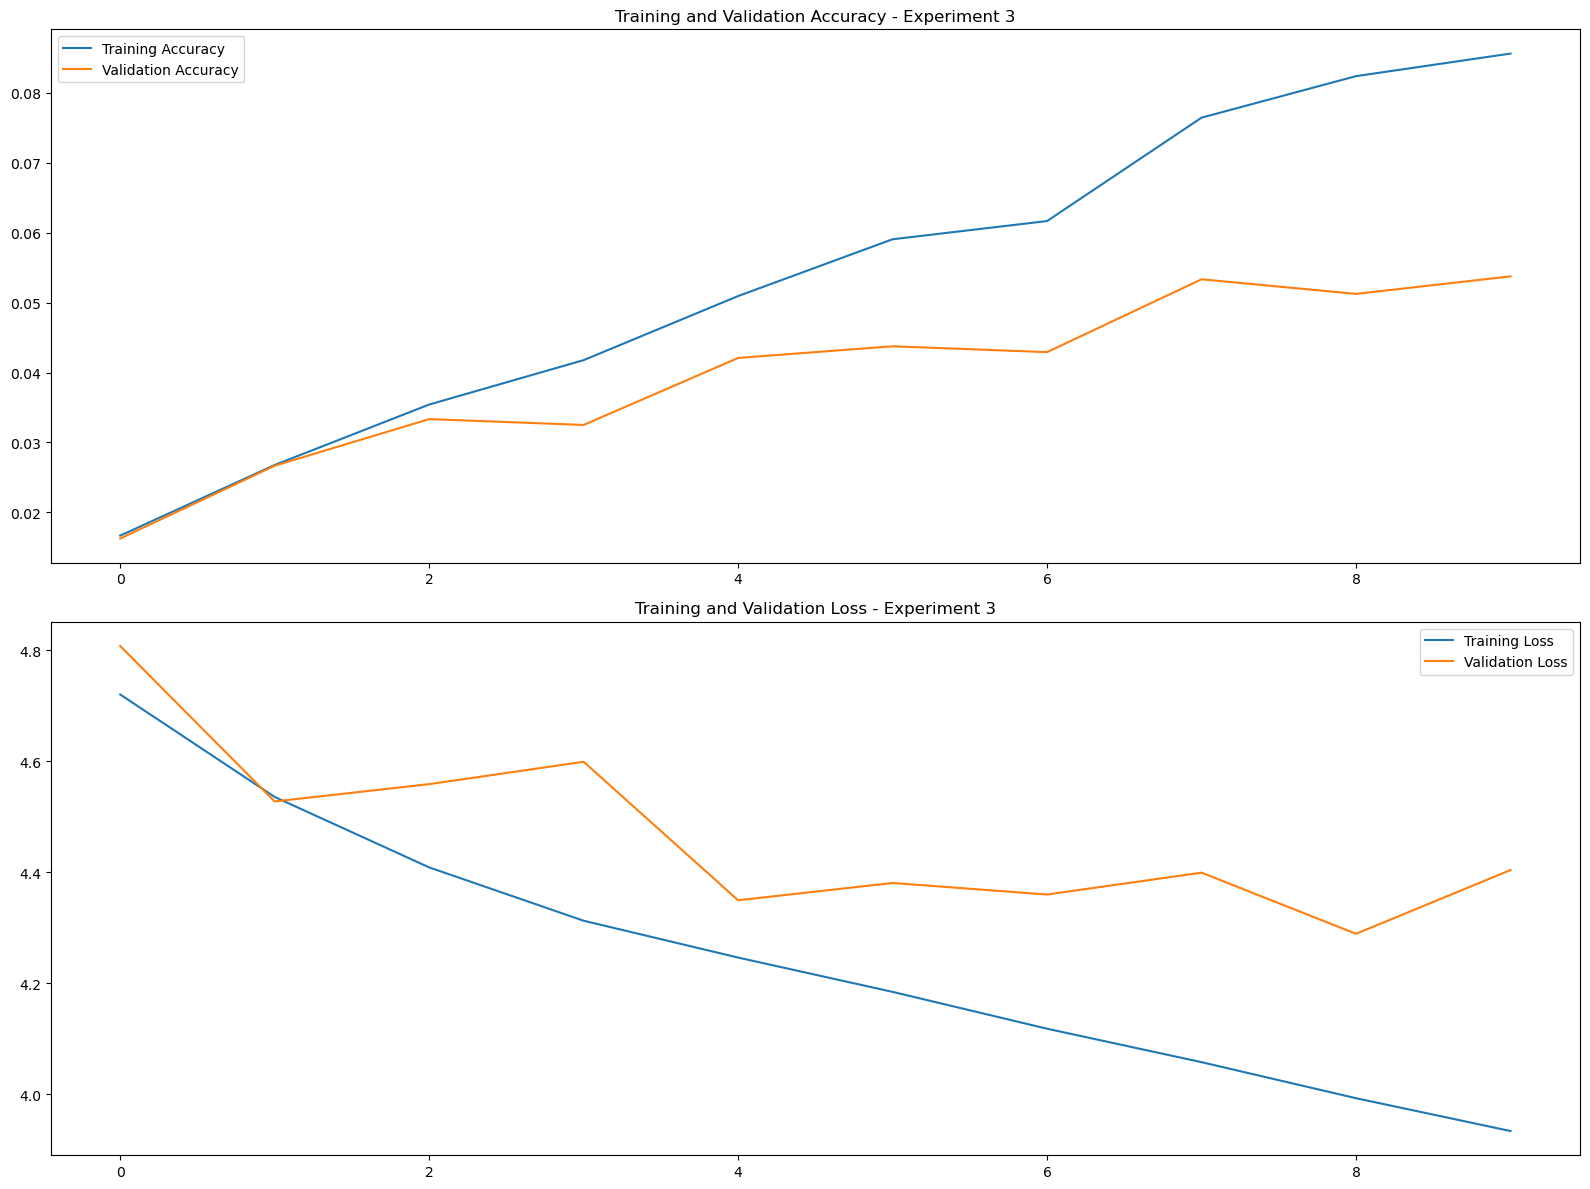

In [ ]:
# Experiment 3: Optimized CNN with Batch Normalization, Smaller Dataset

import random
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

subset_train_dataset = train_dataset.shuffle(10000, seed=42).take(2000)
subset_test_dataset = test_dataset.shuffle(2000, seed=42).take(400)

experiment_3_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

experiment_3_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

experiment_3_cnn.summary()

history_3 = experiment_3_cnn.fit(
    subset_train_dataset,
    validation_data=subset_test_dataset,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("experiment_3_cnn_model.keras", save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
    ]
)

experiment_3_cnn = tf.keras.models.load_model("experiment_3_cnn_model.keras")
test_acc_3 = experiment_3_cnn.evaluate(subset_test_dataset)
print(f"[Experiment 3 - Optimized CNN] Test Accuracy: {test_acc_3[1]:.3f}")

history_dict_3 = history_3.history
history_df_3 = pd.DataFrame(history_dict_3)

plt.figure(figsize=(16, 12))
plt.subplot(211)
plt.plot(history_df_3['accuracy'], label='Training Accuracy')
plt.plot(history_df_3['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy - Experiment 3')
plt.legend()

plt.subplot(212)
plt.plot(history_df_3['loss'], label='Training Loss')
plt.plot(history_df_3['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Experiment 3')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2400 files belonging to 120 classes.
Found 600 files belonging to 120 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.0106 - loss: 21.2817 - precision: 0.0107 - recall: 0.0052 - val_accuracy: 0.0133 - val_loss: 4.8117 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.0127 - loss: 5.0461 - precision: 0.1062 - recall: 4.0107e-04 - val_accuracy: 0.0183 - val_loss: 4.9421 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - accuracy: 0.0173 - loss: 4.8730 - precision: 0.1318 - recall: 4.8245e-04 - val_accuracy: 0.0233 - val_loss: 4.7257 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010

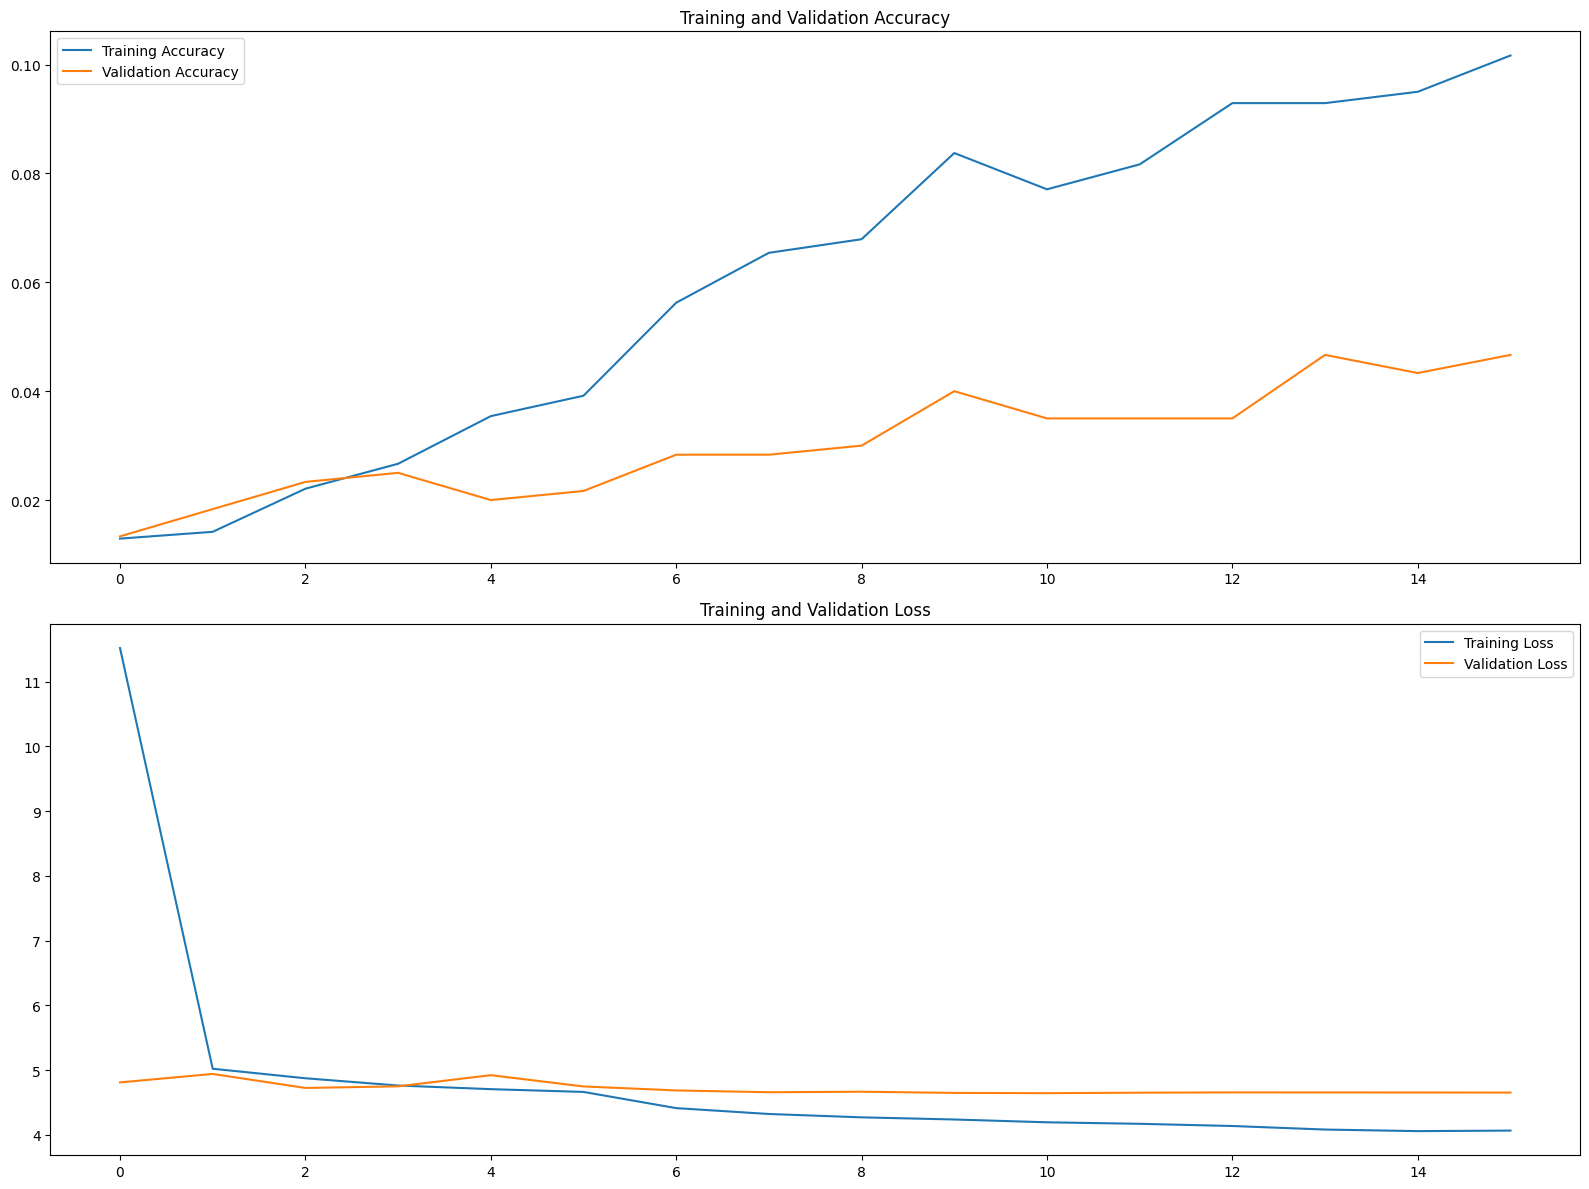

In [ ]:
# === Step 0: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === Step 1: Import Libraries ===
# import tensorflow as tf
# from tensorflow.keras.applications import Xception
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
# from tensorflow.keras.optimizers import RMSprop
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# import matplotlib.pyplot as plt
# import pandas as pd

# === Step 2: Define Dataset Paths ===
train_dir = "/content/drive/MyDrive/MSDS 498 CAPSTONE/PetImagesSmall/small_train"
test_dir = "/content/drive/MyDrive/MSDS 498 CAPSTONE/PetImagesSmall/small_test"
batch_size = 32
img_size = (224, 224)

# === Step 3: Load the Datasets with Categorical Labels ===
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

class_names = train_dataset.class_names

# === Step 4: Optimize Performance with Prefetching ===
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# === Step 5: Build the Xception-Based Model ===
base_model_xception = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_xception.trainable = False  # Freeze base model for feature extraction

experiment_4_model = Sequential([
    base_model_xception,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

# === Step 6: Compile the Model ===
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-07)
experiment_4_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# === Step 7: Callbacks ===
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7)

# === Step 8: Train the Model ===
history_4 = experiment_4_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stopping, reduce_lr]
)

# === Step 9: Save and Evaluate ===
experiment_4_model.save("experiment_4_xception_model.keras")
test_acc_4 = experiment_4_model.evaluate(test_dataset)
print(f"[Experiment 4 - Xception Transfer Learning] Test Accuracy: {test_acc_4[1]:.3f}")

# === Step 10: Plot Results ===
history_df = pd.DataFrame(history_4.history)

plt.figure(figsize=(16, 12))
plt.subplot(211)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(212)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2400 files belonging to 120 classes.
Found 600 files belonging to 120 classes.
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - accuracy: 0.0112 - loss: 26.4552 - precision_1: 0.0132 - recall_1: 0.0070 - val_accuracy: 0.0167 - val_loss: 4.8873 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.0171 - loss: 5.0647 - precision_1: 0.0675 - recall_1: 3.6490e-04 - val_accuracy: 0.0133 - val_loss: 5.1062 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - accuracy: 0.0164 - loss: 4.9029 - precision_1: 0.1243 - recall_1: 3.1575e-04 - val_accuracy: 0.0133 - val_loss: 4.8237 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━

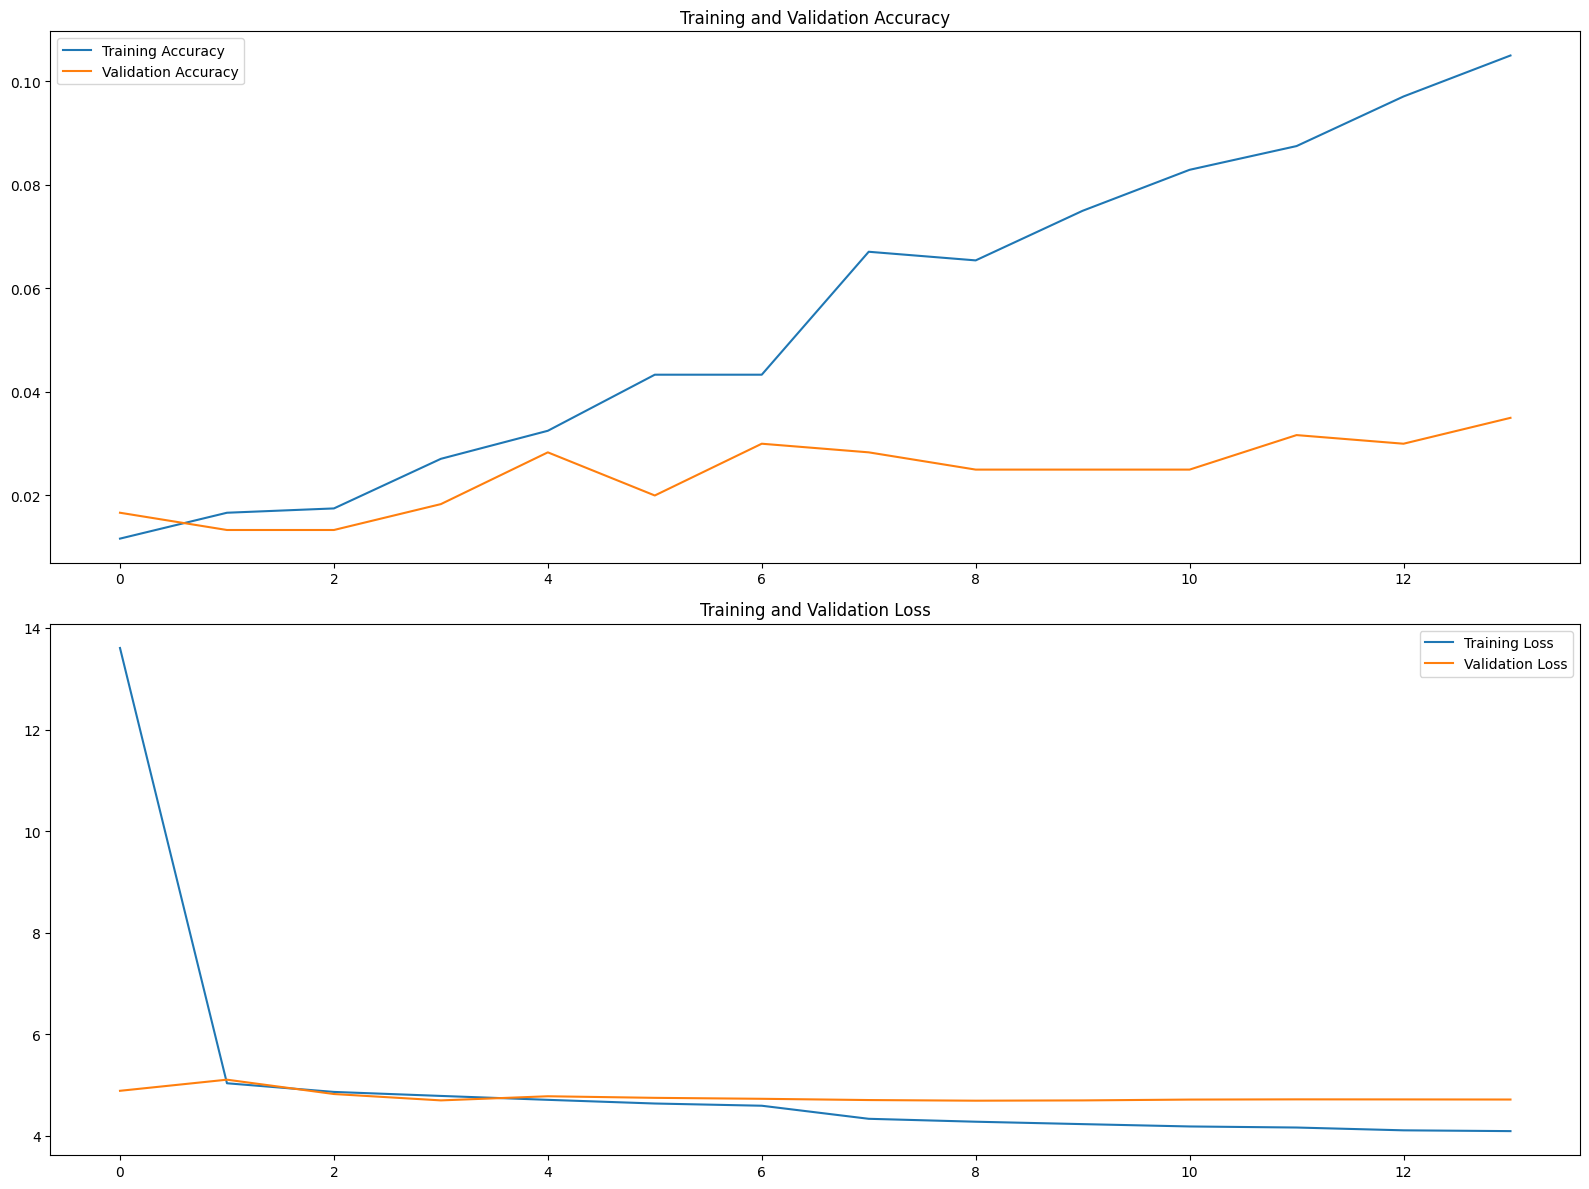

In [ ]:
# === Step 0: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === Step 1: Import Libraries ===
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd

# === Step 2: Define Dataset Paths ===
train_dir = "/content/drive/MyDrive/MSDS 498 CAPSTONE/PetImagesSmall/small_train"
test_dir = "/content/drive/MyDrive/MSDS 498 CAPSTONE/PetImagesSmall/small_test"
batch_size = 32
img_size = (224, 224)

# === Step 3: Load the Datasets with Categorical Labels ===
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

class_names = train_dataset.class_names

# === Step 4: Optimize Performance with Prefetching ===
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# === Step 5: Build the Xception-Based Model ===
base_model_xception = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_xception.trainable = False  # Freeze base model for feature extraction

experiment_5_model = Sequential([
    base_model_xception,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

# === Step 6: Compile the Model ===
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-07)
experiment_5_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# === Step 7: Callbacks ===
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7)

# === Step 8: Train the Model ===
history_5 = experiment_5_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,  # Reduced epochs for faster execution
    callbacks=[early_stopping, reduce_lr]
)

# === Step 9: Save and Evaluate ===
experiment_5_model.save("experiment_5_xception_model.keras")
test_acc_5 = experiment_5_model.evaluate(test_dataset)
print(f"[Experiment 5 - Xception Transfer Learning] Test Accuracy: {test_acc_5[1]:.3f}")

# === Step 10: Plot Results ===
history_df = pd.DataFrame(history_5.history)

plt.figure(figsize=(16, 12))
plt.subplot(211)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(212)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2400 files belonging to 120 classes.
Found 600 files belonging to 120 classes.
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - accuracy: 0.0040 - loss: 11748.7979 - precision_2: 0.0029 - recall_2: 0.0021 - val_accuracy: 0.0083 - val_loss: 8.4093 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.0045 - loss: 10.9076 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.0083 - val_loss: 8.4013 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.0062 - loss: 8.6683 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.0083 - val_loss: 8.3817 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.0057 - loss: 8.5895 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.0083 - val_loss: 8.3979 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - le

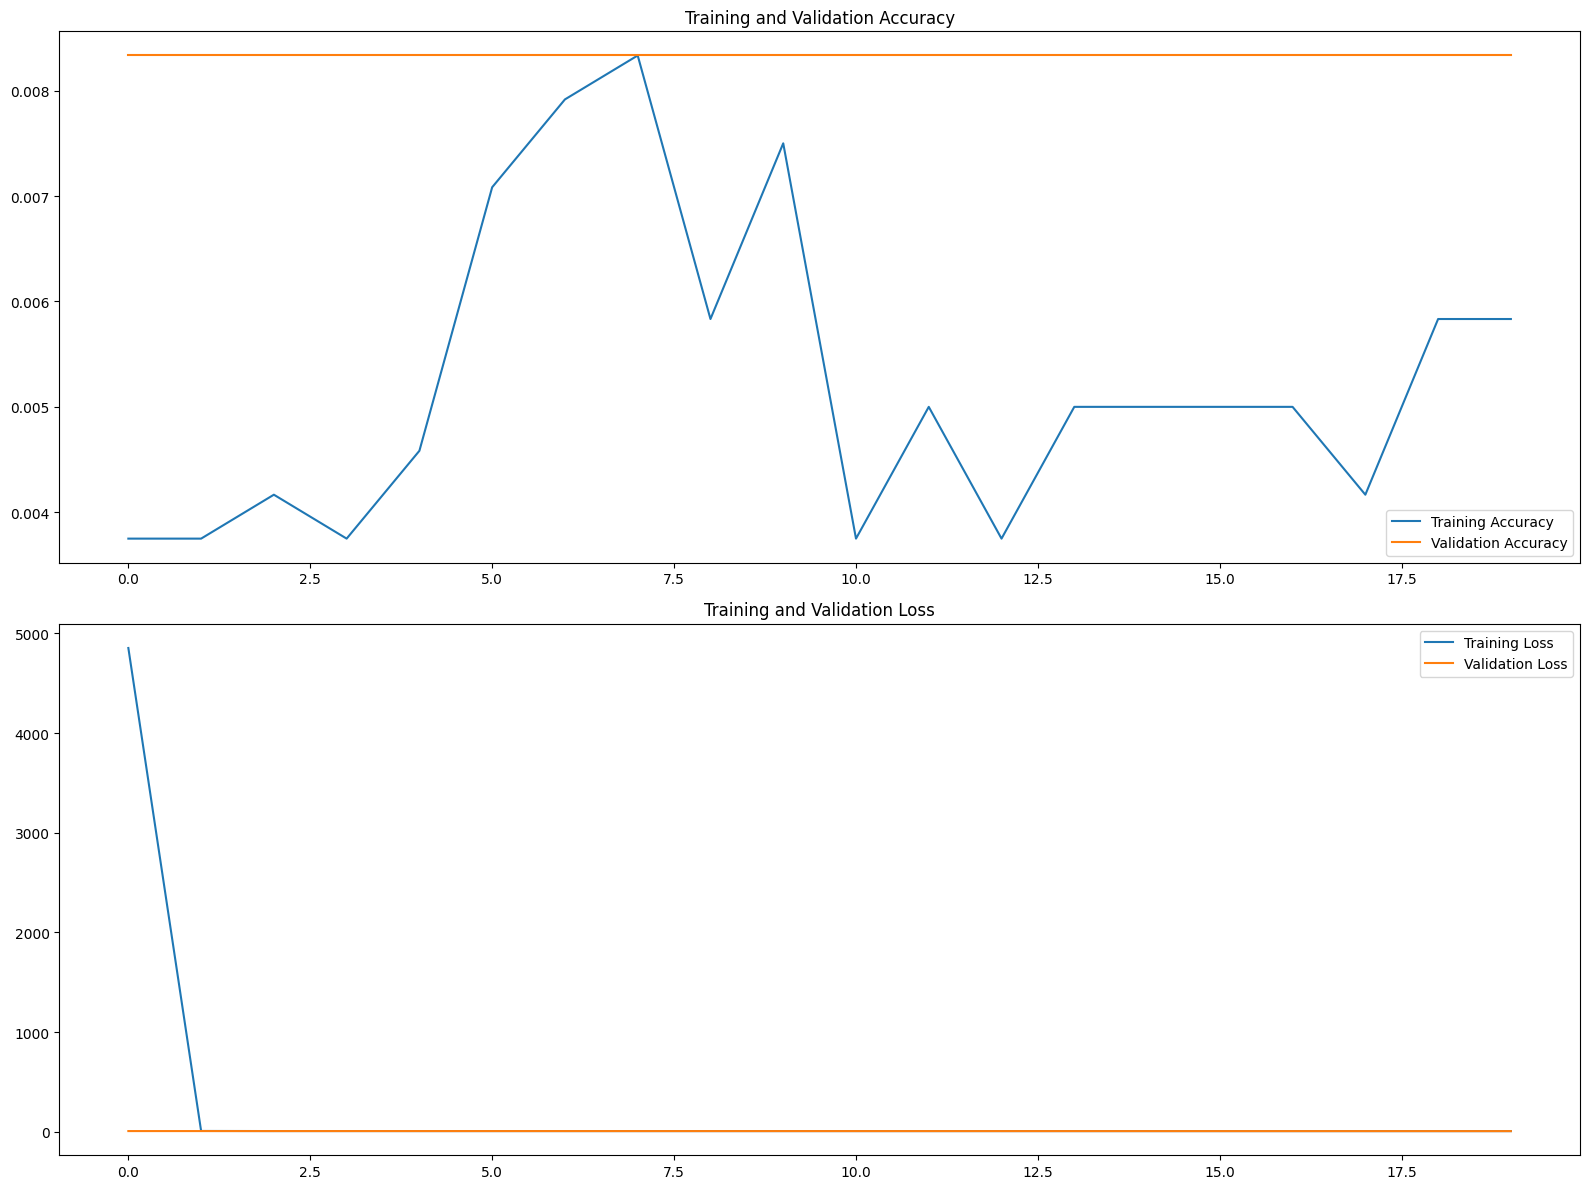

In [ ]:
# === Step 0: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === Step 1: Import Libraries ===
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import pandas as pd

# === Step 2: Define Dataset Paths ===
train_dir = "/content/drive/MyDrive/MSDS 498 CAPSTONE/PetImagesSmall/small_train"
test_dir = "/content/drive/MyDrive/MSDS 498 CAPSTONE/PetImagesSmall/small_test"
batch_size = 32
img_size = (224, 224)

# === Step 3: Load the Datasets with Categorical Labels ===
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

class_names = train_dataset.class_names

# === Step 4: Optimize Performance with Prefetching ===
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# === Step 5: Build the Custom Neural Network Model ===
experiment_6_model = Sequential([
    Flatten(input_shape=(224, 224, 3)),  # Flatten the input
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),  # First hidden layer with L2 regularization
    Dropout(0.5),  # Dropout for regularization
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),  # Second hidden layer with L2 regularization
    Dropout(0.5),  # Dropout for regularization
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),  # Third hidden layer with L2 regularization
    Dropout(0.5),  # Dropout for regularization
    Dense(len(class_names), activation='softmax')  # Output layer with softmax activation
])

# === Step 6: Compile the Model ===
optimizer = Adam(learning_rate=0.001)
experiment_6_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# === Step 7: Callbacks ===
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7)

# === Step 8: Train the Model ===
history_6 = experiment_6_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,  # Reduced epochs for faster execution
    callbacks=[early_stopping, reduce_lr]
)

# === Step 9: Save and Evaluate ===
experiment_6_model.save("experiment_6_custom_nn_model.keras")
test_acc_6 = experiment_6_model.evaluate(test_dataset)
print(f"[Experiment 6 - Custom NN with 3 Hidden Layers] Test Accuracy: {test_acc_6[1]:.3f}")

# === Step 10: Plot Results ===
history_df = pd.DataFrame(history_6.history)

plt.figure(figsize=(16, 12))
plt.subplot(211)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(212)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()